# Detectors

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import torch
import random

In [8]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [35]:
# Initialize detection model
from ultralytics import YOLOE, RTDETR

# Initialize a YOLOE model
yoloe_model = YOLOE("yoloe-11l-seg-pf.pt")
# yoloe_model = YOLOE("yolo12x.pt")

# Load a COCO-pretrained RT-DETR-l model
rtdetr_model = RTDETR("rtdetr-l.pt")

set up the device (mps for macOS, cuda for NVIDIA GPUs, or cpu for CPU-only inference)

In [3]:
import torch

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [28]:
# Run detection
def detect_objects(image_path, model=yoloe_model):
    results = model(image_path)
    # Visualize results
    plt.figure(figsize=(12, 8))
    plt.imshow(results[0].plot()[:, :, ::-1])  # Convert BGR to RGB
    plt.title("Object Detection")
    plt.axis('off')
    plt.show()


image 1/1 /Users/n0man/Code/n03an.me/notebooks/vision/../_asset/vit/virat/condo_parking.png: 384x640 2 barrels, 20 cars, 1 emergency vehicle, 1 information desk, 1 recycling bin, 1 shipping container, 6 suvs, 1 tow truck, 2 trailer trucks, 4 vans, 1 waste container, 138.2ms
Speed: 2.2ms preprocess, 138.2ms inference, 11.0ms postprocess per image at shape (1, 3, 384, 640)


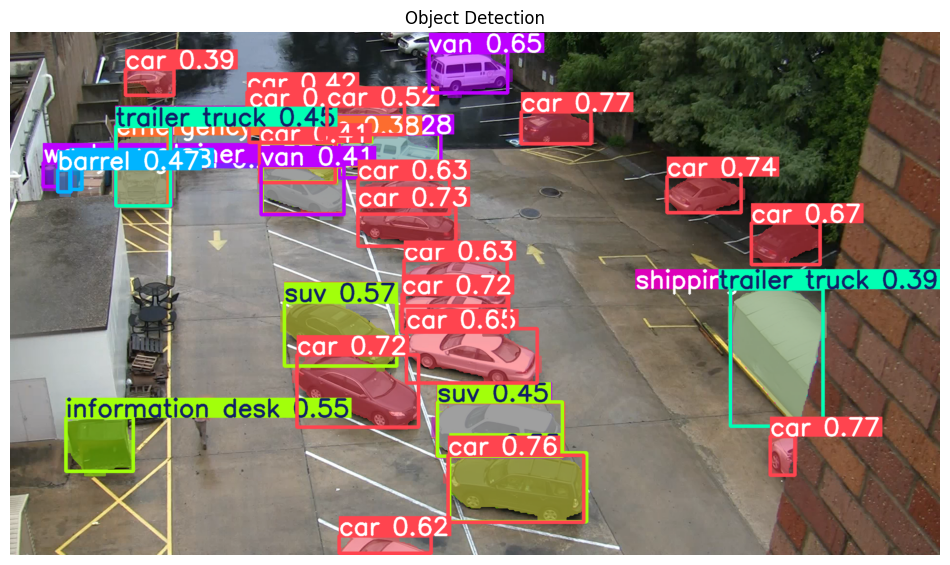


image 1/1 /Users/n0man/Code/n03an.me/notebooks/vision/../_asset/vit/virat/downsample_condo_parking.jpg: 640x640 1 brickwork, 1 bus, 1 cabin car, 11 cars, 1 forklift, 2 persons, 1 pulpit, 1 siding, 14 suvs, 1 ticket booth, 1 tow truck, 1 trailer truck, 1 truck, 4 vans, 1 waste container, 222.0ms
Speed: 0.6ms preprocess, 222.0ms inference, 20.7ms postprocess per image at shape (1, 3, 640, 640)


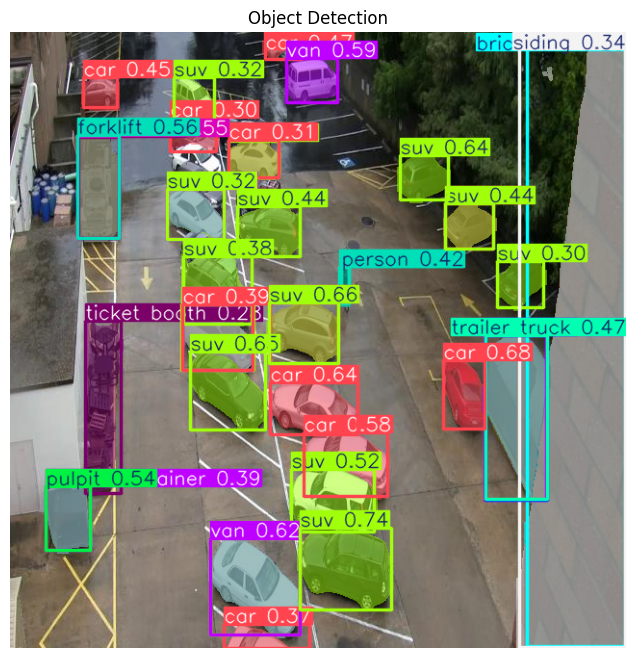


image 1/1 /Users/n0man/Code/n03an.me/notebooks/vision/../_asset/vit/virat/condo_parking.png: 640x640 19 cars, 1 bus, 10 trucks, 215.7ms
Speed: 2.5ms preprocess, 215.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


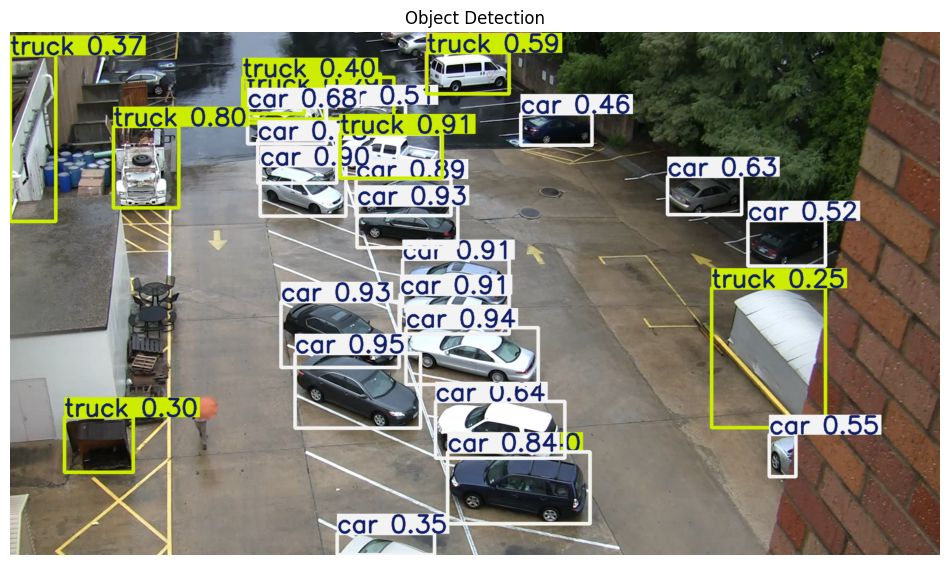

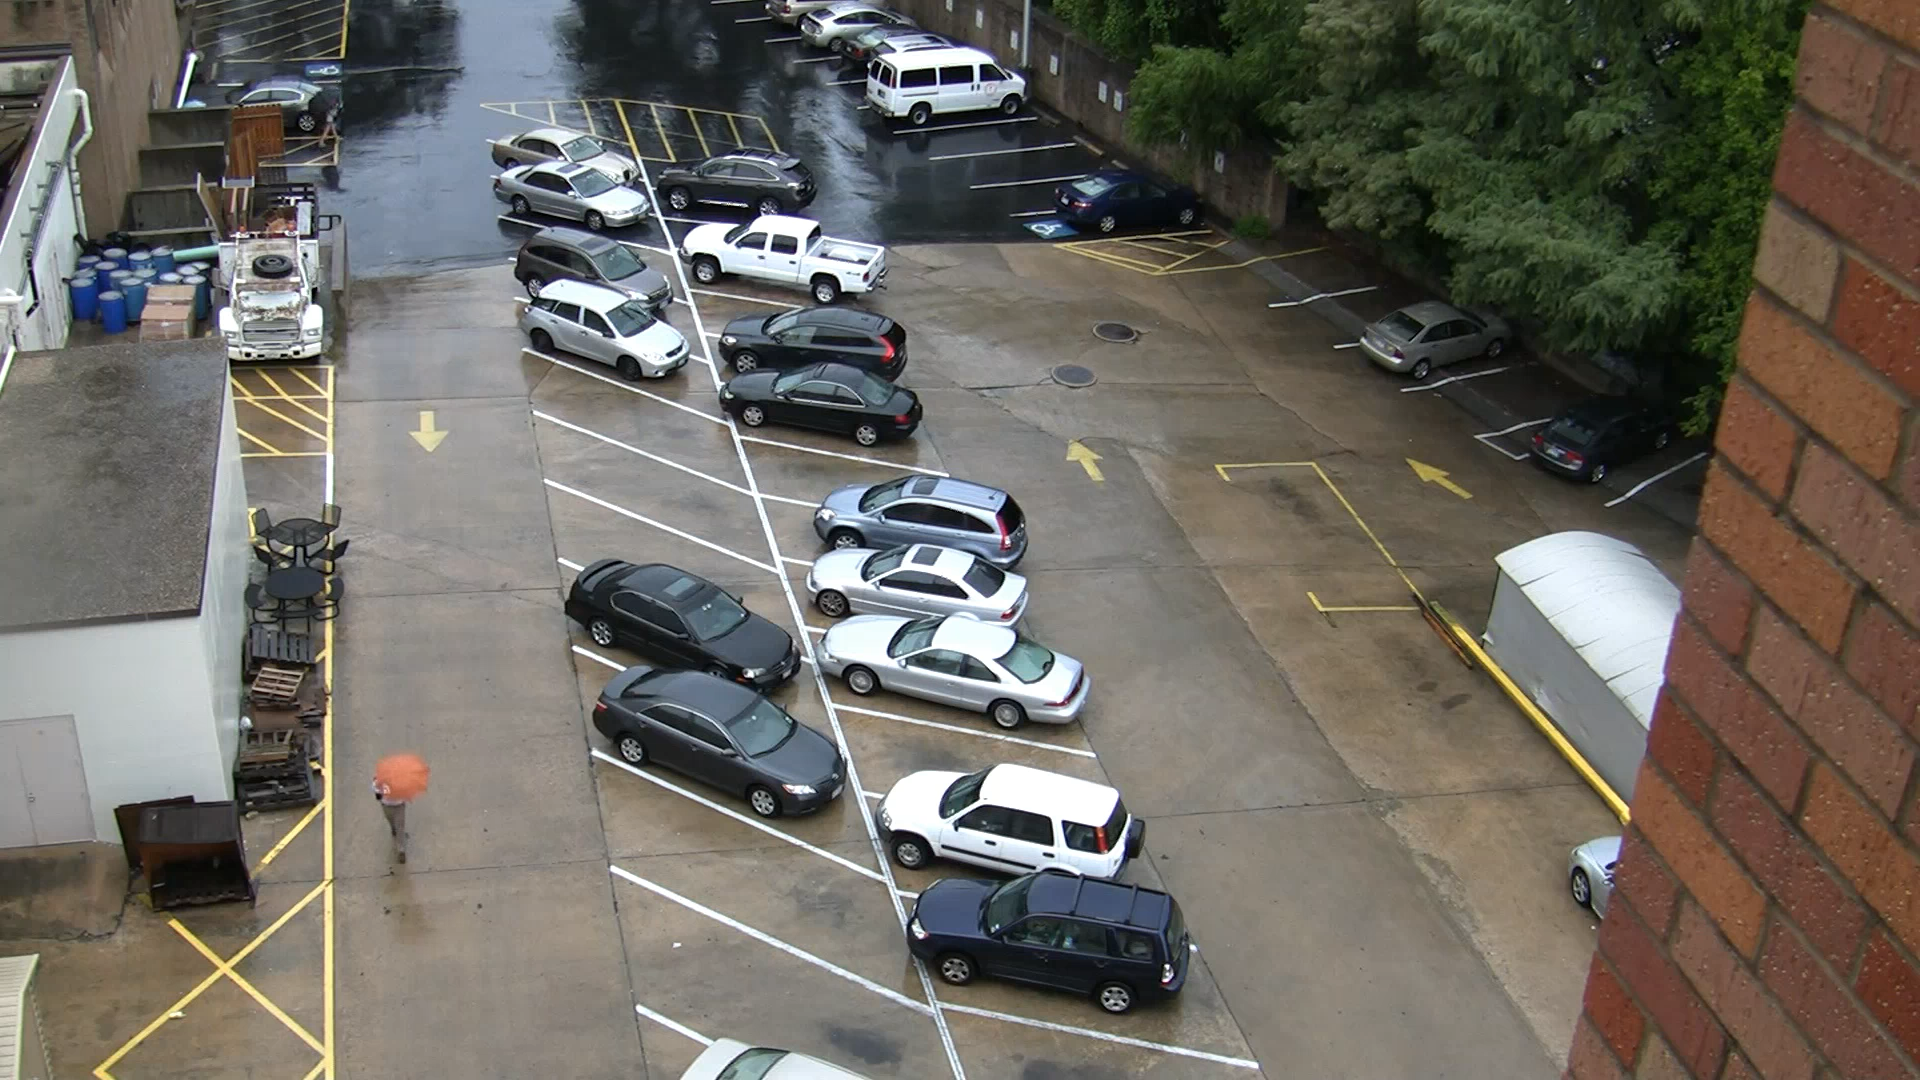

In [37]:
# Run detection
detect_objects("../_asset/vit/virat/condo_parking.png")
detect_objects("../_asset/vit/virat/downsample_condo_parking.jpg")
detect_objects("../_asset/vit/virat/condo_parking.png", model=rtdetr_model)
Image("../_asset/vit/virat/condo_parking.png")

In [27]:
!pip install sahi==0.11.36

  Using cached sahi-0.11.36-py3-none-any.whl.metadata (19 kB)
  Using cached fire-0.7.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached fire-0.7.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
  Using cached pybboxes-0.1.6-py3-none-any.whl.metadata (9.9 kB)
  Using cached pybboxes-0.1.6-py3-none-any.whl.metadata (9.9 kB)
  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached terminaltables-3.1.10-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached shapely-2.1.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached terminaltables-3.1.10-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached sahi-0.11.36-py3-none-any.whl (111 kB)
Using cached pybboxes-0.1.6-py3-none-any.whl (24 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl (37.3 MB)
Using cached

In [4]:
from IPython.display import Image

# Correct local sahi imports (after ensuring repo root is on sys.path in previous cell)
from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction, predict

In [10]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="rtdetr",
    model_path="rtdetr-l.pt",  # any yoloe-11s-seg.pt, yoloe-11m-seg.pt, yoloe-11l-seg.pt,yoloe-v8s-seg.pt, yoloe-v8m-seg.pt, yoloe-v8l-seg.pt model is supported # noqa: E501
    confidence_threshold=0.35,
    device="cpu",  # or 'cuda:0' if GPU is available
)

Performing prediction on 8 slices.


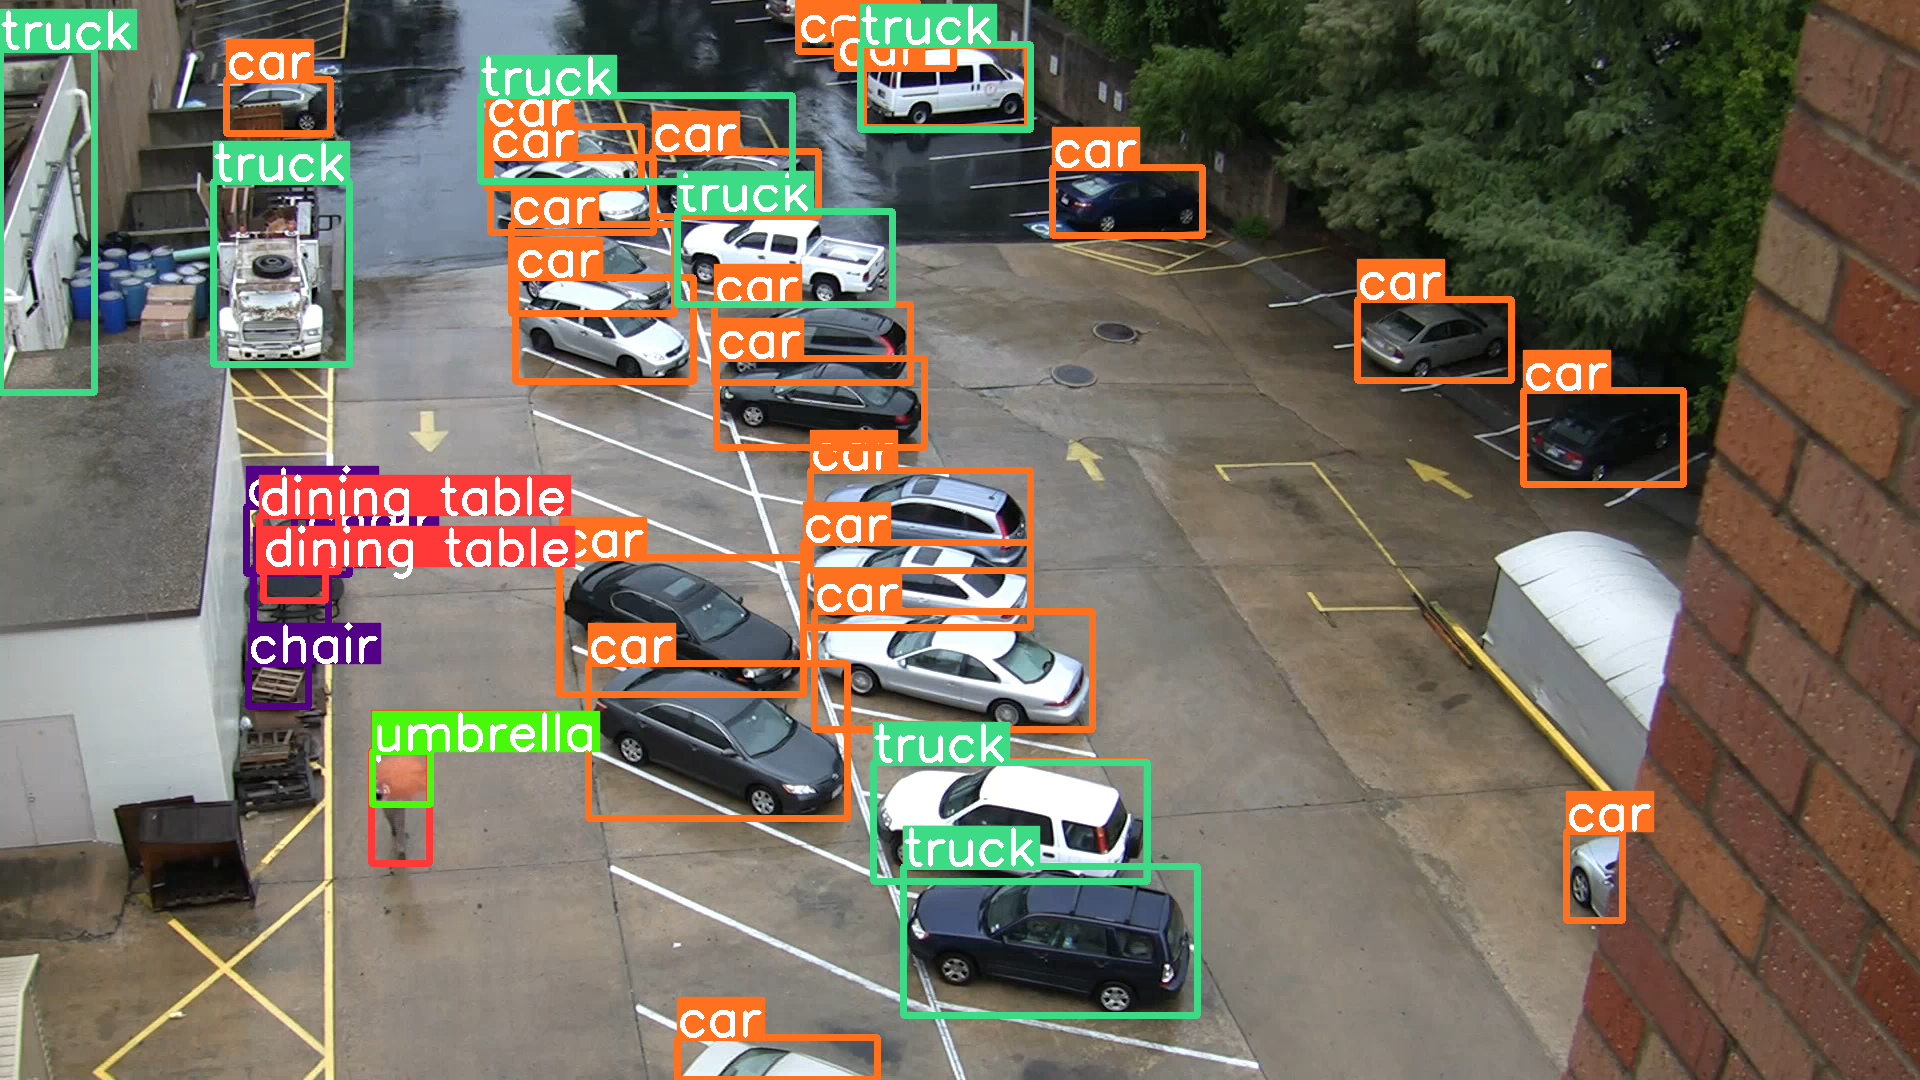

In [19]:
result = get_sliced_prediction(
    "../_asset/vit/virat/condo_parking.png",
    detection_model,
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)
result.export_visuals(export_dir="output/", hide_conf=True)
Image("output/prediction_visual.png")